<a href="https://colab.research.google.com/github/cristinasarakefi-art/TugasAkhirS1/blob/main/Penelitian%2014%20FIXXX%20Untitled38.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
from IPython.display import display, HTML
from google.colab import files

# 1. Upload File CSV
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# 2. Baca Dataset
df = pd.read_csv(file_name, sep=None, engine='python')

# Membersihkan spasi pada nama header kolom
df.columns = df.columns.str.strip()

# Membersihkan spasi pada nilai teks (Nama & Bidang Minat)
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str).str.strip()

# Konversi IPK Semester 3 dari format koma (2,79) ke float (2.79)
df['IPK Semester 3'] = df['IPK Semester 3'].str.replace(',', '.').astype(float)

display(HTML("<b>=== BAGIAN 1: DATASET BERHASIL DI-LOAD ===</b>"))
display(HTML(f"Total Jumlah Data: <b>{len(df)} baris</b>"))
display(df.head())

Saving Data Mentah Penelitian Skripsi 5.csv to Data Mentah Penelitian Skripsi 5 (2).csv


,Nama Lengkap,Bidang Minat,IPK Semester 3,Nilai mata kuliah Dasar Tenaga Listrik,Nilai mata kuliah Dasar Teknik Telekomunikasi,Nilai mata kuliah Dasar Pemrograman Komputer,Nilai Skor Minat TTL,Nilai Skor Minat TTT,Nilai Skor Minat TKK
0,Kristina Sara Sunia Kefi,Teknik Komputer & Kendali,2.79,A,C,C,15,15,29
1,Kartini Riyani Boni Geti,Teknik Telekomunikasi,2.79,A-,B-,C+,17,27,25
2,Fransiska Romana Dua Yustin Nellu,Teknik Telekomunikasi,2.73,A,B+,AB,30,35,32
3,JUFRIDSON LAY WOHE,Teknik Komputer & Kendali,2.48,AB,B-,C,20,7,33
4,Epin Modjo,Teknik Komputer & Kendali,2.91,B+,B-,AB,29,21,35


In [7]:
from sklearn.model_selection import train_test_split

kolom_nama = 'Nama Lengkap'
kolom_target = 'Bidang Minat'
kolom_fitur = [c for c in df.columns if c not in [kolom_nama, kolom_target]]

# Split Data 80:20 berdasarkan indeks baris
train_idx, test_idx = train_test_split(
    df.index, test_size=0.20, random_state=42, stratify=df[kolom_target]
)

# Subset Data Mentah
df_train = df.loc[train_idx].copy()
df_test = df.loc[test_idx].copy()

df_summary = pd.DataFrame({
    'Jenis Data': ['Data Latih (80%)', 'Data Uji (20%)', 'Total Dataset'],
    'Jumlah Baris': [len(df_train), len(df_test), len(df)]
})

display(HTML("<b>=== BAGIAN 2: HASIL PEMISAHAN DATASET (80:20) ===</b>"))
display(df_summary.style.hide(axis='index'))

Jenis Data,Jumlah Baris
Data Latih (80%),80
Data Uji (20%),20
Total Dataset,100


In [8]:
# Pemetaan Nilai Huruf Mata Kuliah ke Skala Bobot 0 - 4
map_nilai = {
    'A': 4.00, 'A-': 3.70, 'AB': 3.50, 'B+': 3.30, 'B': 3.00,
    'B-': 2.70, 'BC': 2.50, 'C+': 2.30, 'C': 2.00, 'C-': 1.70,
    'D+': 1.30, 'D': 1.00, 'E': 0.00
}

kolom_matkul = [
    'Nilai mata kuliah Dasar Tenaga Listrik',
    'Nilai mata kuliah Dasar Teknik Telekomunikasi',
    'Nilai mata kuliah Dasar Pemrograman Komputer'
]
kolom_skor = ['Nilai Skor Minat TTL', 'Nilai Skor Minat TTT', 'Nilai Skor Minat TKK']

def preprocess_and_scale(data_df):
    df_out = data_df.copy()

    # 1. Encoding Nilai Huruf ke Numerik (0 - 4)
    for col in kolom_matkul:
        df_out[col] = df_out[col].map(map_nilai)

    # 2. Min-Max Scaling IPK & Matkul (Xmin = 0, Xmax = 4)
    # Rumus: (X - 0) / (4 - 0) = X / 4
    for col in ['IPK Semester 3'] + kolom_matkul:
        df_out[col] = (df_out[col] - 0) / (4 - 0)

    # 3. Min-Max Scaling Skor Kuesioner (Xmin = 7, Xmax = 35)
    # Rumus: (X - 7) / (35 - 7)
    for col in kolom_skor:
        df_out[col] = (df_out[col] - 7) / (35 - 7)

    return df_out

# Terapkan fungsi preprocessing
df_train_scaled = preprocess_and_scale(df_train)
df_test_scaled = preprocess_and_scale(df_test)

# Matriks Fitur (X) dan Target (y)
X_train = df_train_scaled[kolom_fitur].values
y_train = df_train_scaled[kolom_target].values

X_test = df_test_scaled[kolom_fitur].values
y_test = df_test_scaled[kolom_target].values

display(HTML("<b>=== BAGIAN 3: HASIL NORMALISASI MIN-MAX ===</b>"))
display(HTML("<b>Sampel Data Latih Ter-normalisasi (5 Pertama):</b>"))
display(df_train_scaled[[kolom_nama] + kolom_fitur].head())

,Nama Lengkap,IPK Semester 3,Nilai mata kuliah Dasar Tenaga Listrik,Nilai mata kuliah Dasar Teknik Telekomunikasi,Nilai mata kuliah Dasar Pemrograman Komputer,Nilai Skor Minat TTL,Nilai Skor Minat TTT,Nilai Skor Minat TKK
77,Natalino Rangga Anin,0.7750,0.675,0.575,0.750,1.000000,0.428571,0.928571
91,Rafles Riwu Djeta,0.8300,0.750,1.000,0.675,0.535714,0.821429,0.678571
32,Jesifeansy Benu,0.6550,0.875,0.825,0.875,0.392857,0.678571,0.392857
31,Ficha keo,0.5900,0.875,0.575,0.625,0.321429,0.642857,0.571429
53,KRISTOFORUS BEDA BEGUIR,0.6275,0.875,0.575,0.675,0.464286,0.964286,0.285714


In [9]:
def hitung_euclidean_distance(x1, x2):
    # Rumus: akar dari jumlah kuadrat selisih antar fitur
    return np.sqrt(np.sum((x1 - x2) ** 2))

# Contoh Perhitungan Jarak untuk Data Uji Ke-1 (Indeks 0)
idx_uji = 0
sampel_uji = X_test[idx_uji]
nama_uji = df_test.iloc[idx_uji][kolom_nama]

daftar_jarak = []
for i in range(len(X_train)):
    jarak = hitung_euclidean_distance(sampel_uji, X_train[i])
    daftar_jarak.append({
        'Nama Data Latih': df_train.iloc[i][kolom_nama],
        'Bidang Minat (Kelas)': y_train[i],
        'Euclidean Distance': jarak
    })

# Konversi ke DataFrame dan Urutkan secara Ascending
df_jarak = pd.DataFrame(daftar_jarak)
df_jarak_sorted = df_jarak.sort_values(by='Euclidean Distance', ascending=True).reset_index(drop=True)

display(HTML(f"<b>=== BAGIAN 4: PERHITUNGAN & PENGURUTAN JARAK (Data Uji 1: {nama_uji}) ===</b>"))
display(HTML("<b>11 Tetangga Terdekat (Top 11 Ascending):</b>"))
display(df_jarak_sorted.head(11))

,Nama Data Latih,Bidang Minat (Kelas),Euclidean Distance
0,Victoria christin Tokan,Teknik Komputer & Kendali,0.171570
1,Yohana Palestrina Kobesi,Teknik Komputer & Kendali,0.223691
2,Epin Modjo,Teknik Komputer & Kendali,0.271888
3,Vickry Adinarto Fuah,Teknik Komputer & Kendali,0.286739
4,Yedija Wiliems Mooy,Teknik Komputer & Kendali,0.328945
5,Reynaldi Hadi Djo,Teknik Komputer & Kendali,0.329682
6,OVI HALENA TALAEN,Teknik Komputer & Kendali,0.353582
7,cristo sutiray,Teknik Komputer & Kendali,0.406491
8,Phylia Chisty Boimau,Teknik Komputer & Kendali,0.414522
9,Aldion Frankie Djahe,Teknik Komputer & Kendali,0.435881


In [10]:
from collections import Counter

def prediksi_knn_tunggal(X_tr, y_tr, x_te, k):
    distances = [hitung_euclidean_distance(x_te, x_sampel) for x_sampel in X_tr]
    idx_k_terdekat = np.argsort(distances)[:k]
    label_k_terdekat = [y_tr[i] for i in idx_k_terdekat]

    # Voting suara terbanyak
    voting = Counter(label_k_terdekat)
    hasil_prediksi = voting.most_common(1)[0][0]
    return hasil_prediksi, voting, label_k_terdekat

# Prediksi untuk Data Uji Ke-1 dengan K=11
k_pilihan = 11
prediksi, hasil_voting, label_tetangga = prediksi_knn_tunggal(X_train, y_train, sampel_uji, k=k_pilihan)

display(HTML(f"<b>=== BAGIAN 5: KLASIFIKASI VOTING (K={k_pilihan}) ===</b>"))
display(HTML(f"Mahasiswa Uji: <b>{nama_uji}</b>"))
display(HTML(f"Kelas Aktual: <b>{y_test[idx_uji]}</b>"))
display(HTML(f"Hasil Prediksi Sistem: <b>{prediksi}</b>"))
display(HTML(f"Rincian Perolehan Suara Voting: {dict(hasil_voting)}"))

In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

list_k = [3, 5, 7, 9, 11]
hasil_evaluasi = []

for k in list_k:
    y_pred_list = []
    for x_te in X_test:
        pred, _, _ = prediksi_knn_tunggal(X_train, y_train, x_te, k=k)
        y_pred_list.append(pred)

    acc = accuracy_score(y_test, y_pred_list)
    hasil_evaluasi.append({
        'Nilai K': f"K = {k}",
        'Akurasi (%)': round(acc * 100, 2)
    })

df_eval = pd.DataFrame(hasil_evaluasi)

display(HTML("<b>=== BAGIAN 6: EVALUASI PERFORMA NILAI K ===</b>"))
display(df_eval.style.hide(axis='index'))

# Tampilkan Confusion Matrix Khusus K = 11
y_pred_k11 = [prediksi_knn_tunggal(X_train, y_train, x_te, k=11)[0] for x_te in X_test]
labels_unik = sorted(list(set(y_train)))
cm = confusion_matrix(y_test, y_pred_k11, labels=labels_unik)
df_cm = pd.DataFrame(cm, index=[f"Aktual: {l}" for l in labels_unik], columns=[f"Prediksi: {l}" for l in labels_unik])

display(HTML("<br><b>Tabel Confusion Matrix (K = 11):</b>"))
display(df_cm)

Nilai K,Akurasi (%)
K = 3,85.000000
K = 5,85.000000
K = 7,80.000000
K = 9,80.000000
K = 11,80.000000


,Prediksi: Teknik Komputer & Kendali,Prediksi: Teknik Telekomunikasi,Prediksi: Teknik Tenaga Listrik
Aktual: Teknik Komputer & Kendali,4,2,0
Aktual: Teknik Telekomunikasi,0,7,0
Aktual: Teknik Tenaga Listrik,1,1,5


Bidang Minat (Kelas),Precision,Recall,F1-Score
Teknik Komputer & Kendali,0.833300,0.833300,0.833300
Teknik Telekomunikasi,0.777800,1.000000,0.875000
Teknik Tenaga Listrik,1.000000,0.714300,0.833300
Rata-rata Terbobot (Weighted Avg),0.872200,0.850000,0.847900


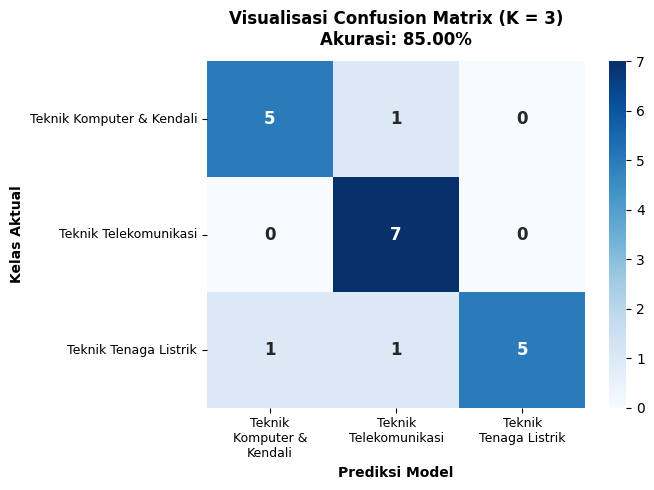

Bidang Minat (Kelas),Precision,Recall,F1-Score
Teknik Komputer & Kendali,1.000000,0.666700,0.800000
Teknik Telekomunikasi,0.700000,1.000000,0.823500
Teknik Tenaga Listrik,1.000000,0.857100,0.923100
Rata-rata Terbobot (Weighted Avg),0.895000,0.850000,0.851300


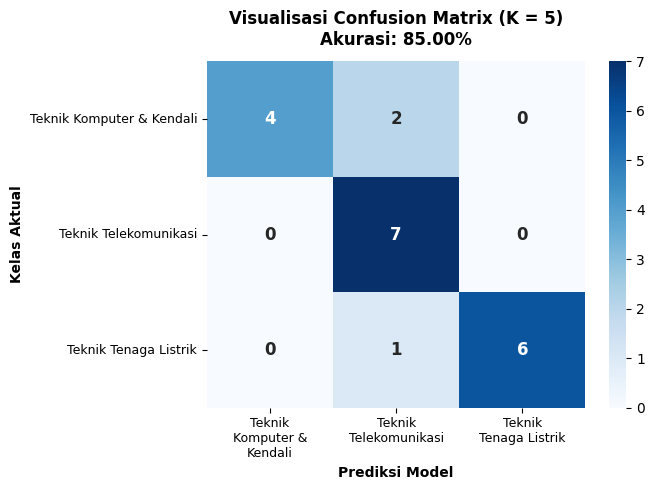

Bidang Minat (Kelas),Precision,Recall,F1-Score
Teknik Komputer & Kendali,0.714300,0.833300,0.769200
Teknik Telekomunikasi,0.777800,1.000000,0.875000
Teknik Tenaga Listrik,1.000000,0.571400,0.727300
Rata-rata Terbobot (Weighted Avg),0.836500,0.800000,0.791600


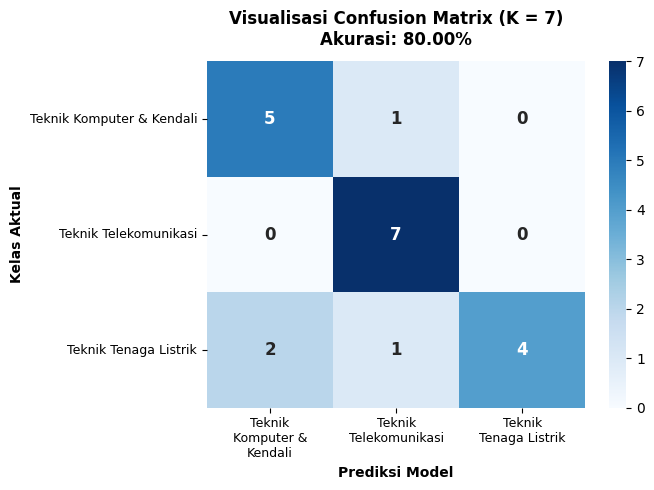

Bidang Minat (Kelas),Precision,Recall,F1-Score
Teknik Komputer & Kendali,0.714300,0.833300,0.769200
Teknik Telekomunikasi,0.777800,1.000000,0.875000
Teknik Tenaga Listrik,1.000000,0.571400,0.727300
Rata-rata Terbobot (Weighted Avg),0.836500,0.800000,0.791600


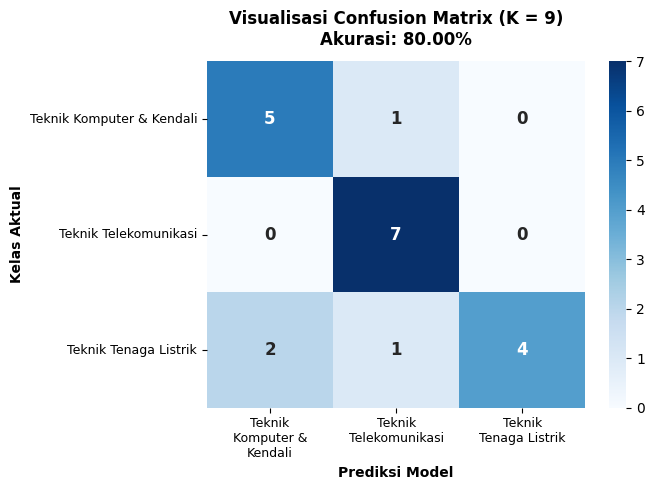

Bidang Minat (Kelas),Precision,Recall,F1-Score
Teknik Komputer & Kendali,0.800000,0.666700,0.727300
Teknik Telekomunikasi,0.700000,1.000000,0.823500
Teknik Tenaga Listrik,1.000000,0.714300,0.833300
Rata-rata Terbobot (Weighted Avg),0.835000,0.800000,0.798100


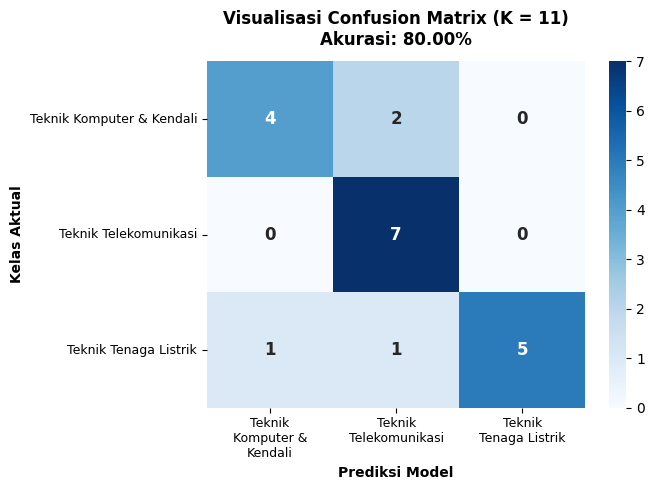

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

list_k = [3, 5, 7, 9, 11]
labels_unik = sorted(list(set(y_train)))

# Membuat format label dengan perpindahan baris (\n) agar teks panjang tidak bertumpuk saat lurus
labels_formatted = [l.replace(" & ", " &\n").replace("Teknik ", "Teknik\n") for l in labels_unik]

display(HTML("<h2><b>=== EVALUASI PERFORMA MODEL UNTUK SETIAP NILAI K ===</b></h2>"))

for k in list_k:
    # 1. Prediksi Data Uji
    y_pred_k = []
    for x_te in X_test:
        pred, _, _ = prediksi_knn_tunggal(X_train, y_train, x_te, k=k)
        y_pred_k.append(pred)

    # 2. Hitung Metrik Evaluasi
    acc = accuracy_score(y_test, y_pred_k)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_k, labels=labels_unik)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_test, y_pred_k, average='weighted')

    display(HTML(f"<hr><h3 style='color:#1F77B4;'><b>Evaluasi Model K-NN dengan Nilai K = {k} (Akurasi: {acc*100:.2f}%)</b></h3>"))

    # 3. Tabel Metrik
    df_metrics = pd.DataFrame({
        'Bidang Minat (Kelas)': labels_unik + ['Rata-rata Terbobot (Weighted Avg)'],
        'Precision': [round(p, 4) for p in precision] + [round(p_macro, 4)],
        'Recall': [round(r, 4) for r in recall] + [round(r_macro, 4)],
        'F1-Score': [round(f, 4) for f in f1] + [round(f1_macro, 4)]
    })

    display(HTML(f"<b>Tabel Presisi, Recall, dan F1-Score untuk K = {k}:</b>"))
    display(df_metrics.style.hide(axis='index'))

    # 4. Visualisasi Heatmap Confusion Matrix (Label Lurus / Horizontal)
    cm = confusion_matrix(y_test, y_pred_k, labels=labels_unik)

    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels_formatted,
                yticklabels=labels_unik,
                cbar=True, annot_kws={"size": 12, "weight": "bold"})

    plt.title(f'Visualisasi Confusion Matrix (K = {k})\nAkurasi: {acc*100:.2f}%', fontsize=12, fontweight='bold', pad=12)
    plt.xlabel('Prediksi Model', fontsize=10, fontweight='bold')
    plt.ylabel('Kelas Aktual', fontsize=10, fontweight='bold')

    # Pengaturan label sumbu X dan Y agar lurus (rotation=0)
    plt.xticks(rotation=0, ha='center', fontsize=9)
    plt.yticks(rotation=0, va='center', fontsize=9)
    plt.tight_layout()
    plt.show()

In [12]:
from sklearn.model_selection import StratifiedKFold

# Preprocessing seluruh dataset (100 data)
df_all_scaled = preprocess_and_scale(df)
X_all = df_all_scaled[kolom_fitur].values
y_all = df_all_scaled[kolom_target].values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skf_results = []

fold = 1
for train_index, test_index in skf.split(X_all, y_all):
    X_tr_fold, X_te_fold = X_all[train_index], X_all[test_index]
    y_tr_fold, y_te_fold = y_all[train_index], y_all[test_index]

    # Evaluasi dengan K=11 pada setiap fold
    y_pred_fold = [prediksi_knn_tunggal(X_tr_fold, y_tr_fold, x_val, k=11)[0] for x_val in X_te_fold]
    acc_fold = accuracy_score(y_te_fold, y_pred_fold)

    skf_results.append({
        'Fold': f"Fold-{fold}",
        'Jumlah Data Latih': len(X_tr_fold),
        'Jumlah Data Uji': len(X_te_fold),
        'Akurasi (%)': round(acc_fold * 100, 2)
    })
    fold += 1

df_cv = pd.DataFrame(skf_results)
rata_rata_ak = round(df_cv['Akurasi (%)'].mean(), 2)

display(HTML("<b>=== BAGIAN 7: HASIL 5-FOLD CROSS VALIDATION (K = 11) ===</b>"))
display(df_cv.style.hide(axis='index'))
display(HTML(f"<h3>Rata-rata Akurasi 5-Fold Cross Validation: <span style='color:green;'>{rata_rata_ak}%</span></h3>"))

Fold,Jumlah Data Latih,Jumlah Data Uji,Akurasi (%)
Fold-1,80,20,85.000000
Fold-2,80,20,90.000000
Fold-3,80,20,100.000000
Fold-4,80,20,100.000000
Fold-5,80,20,90.000000
